# Bank Customer Churn Analysis Using SQL & Python

## Project Overview
This project analyzes a real-world banking customer dataset containing 10,000+ customer records. The analysis uses SQL queries and Python to explore customer demographics, account balances, credit scores, and churn behavior.

## Technologies Used
- Python
- SQL (SQLite)
- Pandas
- Matplotlib

## Objectives
- Analyze customer churn patterns
- Study balance distributions
- Explore salary trends
- Compare customer demographics
- Generate business insights through SQL analysis

## Dataset
Bank Customer Churn Dataset (10,000+ records)

## Author
Simi Dubey


In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/shrutimechlearn/churn-modelling/Churn_Modelling.csv')

df.head()

!pip install pandasql
import pandas as pd
import sqlite3

from pandasql import sqldf

query = """
SELECT Geography,
AVG(Balance) AS AvgBalance
FROM df
GROUP BY Geography
"""

sqldf(query)


,Geography,AvgBalance
0,France,62092.636516
1,Germany,119730.116134
2,Spain,61818.147763


In [2]:
conn = sqlite3.connect("banking.db")

In [3]:
df.to_sql(
    "Customers",
    conn,
    if_exists="replace",
    index=False
)

print("Table Created Successfully")

Table Created Successfully


In [4]:
def run_query(query):
    return pd.read_sql_query(query, conn)
query = """
SELECT COUNT(*) AS Total_Customers
FROM Customers;
"""

run_query(query)

,Total_Customers
0,10000


In [5]:
#average balance
query = """
SELECT ROUND(AVG(Balance),2) AS Average_Balance
FROM Customers;
"""

run_query(query)

,Average_Balance
0,76485.89


In [6]:
#top 10 highest balance 
query = """
SELECT CustomerId,
       Surname,
       Balance
FROM Customers
ORDER BY Balance DESC
LIMIT 10;
"""

run_query(query)

,CustomerId,Surname,Balance
0,15757408,Lo,250898.09
1,15715622,To Rot,238387.56
2,15714241,Haddon,222267.63
3,15571958,McIntosh,221532.80
4,15586674,Shaw,216109.88
5,15599131,Dilke,214346.96
6,15594408,Chia,213146.20
7,15769818,Moore,212778.20
8,15620268,Thomson,212696.32
9,15780212,Mao,212692.97


In [7]:
#customer count by country
query = """
SELECT Geography,
       COUNT(*) AS Customers
FROM Customers
GROUP BY Geography;
"""

run_query(query)

,Geography,Customers
0,France,5014
1,Germany,2509
2,Spain,2477


In [8]:
#average balance by country
query = """
SELECT Geography,
       ROUND(AVG(Balance),2) AS AvgBalance
FROM Customers
GROUP BY Geography;
"""

run_query(query)

,Geography,AvgBalance
0,France,62092.64
1,Germany,119730.12
2,Spain,61818.15


In [9]:
#gender distribution
query = """
SELECT Gender,
       COUNT(*) AS Total
FROM Customers
GROUP BY Gender;
"""

run_query(query)

,Gender,Total
0,Female,4543
1,Male,5457


In [10]:
#churn analysis
query = """
SELECT Exited,
       COUNT(*) AS Customers
FROM Customers
GROUP BY Exited;
"""

run_query(query)

,Exited,Customers
0,0,7963
1,1,2037


In [11]:
#average age by churn
query = """
SELECT Exited,
       ROUND(AVG(Age),2) AS AvgAge
FROM Customers
GROUP BY Exited;
"""

run_query(query)

,Exited,AvgAge
0,0,37.41
1,1,44.84


In [12]:
# active member analysis

query = """
SELECT IsActiveMember,
       COUNT(*) AS Customers
FROM Customers
GROUP BY IsActiveMember;
"""

run_query(query)

,IsActiveMember,Customers
0,0,4849
1,1,5151


In [13]:
#credit score statistics

query = """
SELECT
MIN(CreditScore) AS Minimum,
MAX(CreditScore) AS Maximum,
ROUND(AVG(CreditScore),2) AS Average
FROM Customers;
"""

run_query(query)# highest salary customers

query = """
SELECT CustomerId,
       Surname,
       EstimatedSalary
FROM Customers
ORDER BY EstimatedSalary DESC
LIMIT 10;
"""

run_query(query)


,CustomerId,Surname,EstimatedSalary
0,15662021,Lucciano,199992.48
1,15634359,Dyer,199970.74
2,15697270,Gannon,199953.33
3,15762331,Moss,199929.17
4,15709136,Adams,199909.32
5,15741719,DeRose,199862.75
6,15682834,Johnstone,199857.47
7,15804211,Oluchukwu,199841.32
8,15815656,Hopkins,199808.10
9,15687913,Mai,199805.63


In [14]:
# highest salary customers

query = """
SELECT CustomerId,
       Surname,
       EstimatedSalary
FROM Customers
ORDER BY EstimatedSalary DESC
LIMIT 10;
"""

run_query(query)


,CustomerId,Surname,EstimatedSalary
0,15662021,Lucciano,199992.48
1,15634359,Dyer,199970.74
2,15697270,Gannon,199953.33
3,15762331,Moss,199929.17
4,15709136,Adams,199909.32
5,15741719,DeRose,199862.75
6,15682834,Johnstone,199857.47
7,15804211,Oluchukwu,199841.32
8,15815656,Hopkins,199808.10
9,15687913,Mai,199805.63


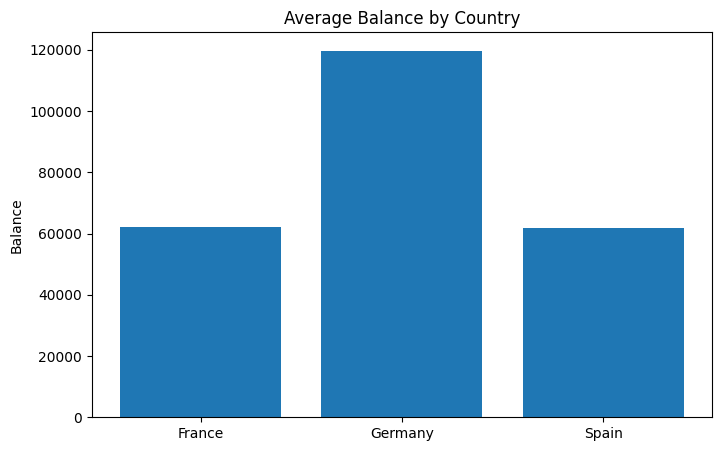

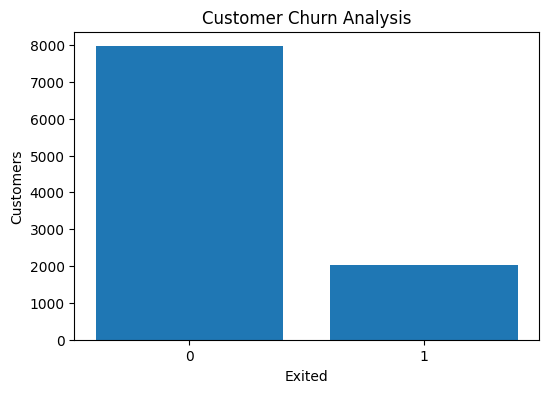

In [15]:
import matplotlib.pyplot as plt

query = """
SELECT Geography,
       AVG(Balance) AS AvgBalance
FROM Customers
GROUP BY Geography;
"""

result = run_query(query)

plt.figure(figsize=(8,5))
plt.bar(result["Geography"], result["AvgBalance"])
plt.title("Average Balance by Country")
plt.ylabel("Balance")
plt.show()

query = """
SELECT Exited,
       COUNT(*) AS Customers
FROM Customers
GROUP BY Exited;
"""

result = run_query(query)

plt.figure(figsize=(6,4))
plt.bar(result["Exited"].astype(str),
        result["Customers"])

plt.title("Customer Churn Analysis")
plt.xlabel("Exited")
plt.ylabel("Customers")
plt.show()

# Findings

- Total customers analyzed: 10,000
- France has the highest number of customers.
- Average customer balance is approximately 76K.
- Customers who exited tend to be older.
- Active members have lower churn.
- Higher balances are concentrated among fewer customers.